# 03 — Approximate Markovianity and informed scores (Layer 4)

Gaussian non-Markov models, exact linear algebra everywhere.

- **Model A**: $a=(y+\beta g)/\sqrt{1+\beta^2}$ with $y$ AR(1), $g$ a global latent.
  For the naive chain approximation the score residual is **exactly rank one** at every
  $t$ (Woodbury): $s_{\rm true}-s_{\rm chain} = c_t(x)\, \Sigma_{t}^{-1}\mathbf{1}$ —
  a fixed smooth direction with an $x$-linear coefficient.
- **Model B**: precision $Q = Q_{\rm AR1}+\gamma Q_{\rm long}$ — a genuinely
  higher-rank correction.
- **Hybrid learning**: direct MLP score vs (frozen) Markov-BP score + MLP *residual*,
  trained on exact-score targets.

Rerun: `python experiments/exp_04_approx_markovianity.py`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

OUT = Path("..") / "outputs"
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
def show(*names, exp):
    for n in names:
        display(Image(filename=str(OUT / exp / n)))


In [2]:
exp = "exp_04_approx_markovianity"
res = pd.read_csv(OUT / exp / "residual_operator_analysis.csv")
res[(res.model == "A_beta") & (res.t == 0.2)][
    ["strength", "approx", "rel_residual_median", "sv2_over_sv1", "effective_rank"]
]

,strength,approx,rel_residual_median,sv2_over_sv1,effective_rank
6,0.1,naive_chain,0.001886,6.34e-13,1
7,0.1,chow_liu,0.002016,0.5681,24.18
22,0.25,naive_chain,0.01167,8.503e-14,1
23,0.25,chow_liu,0.01113,0.7282,24.99
38,0.5,naive_chain,0.0367,2.507e-14,1
39,0.5,chow_liu,0.03243,0.8568,25.24
54,1,naive_chain,0.08647,1.787e-14,1
55,1,chow_liu,0.06594,0.8394,20.8


The naive chain's residual operator has $\sigma_2/\sigma_1 \sim 10^{-12}$: *exactly*
rank one. The Chow-Liu chain has smaller residual *norm* but spreads it over more
directions — structure and norm trade off.

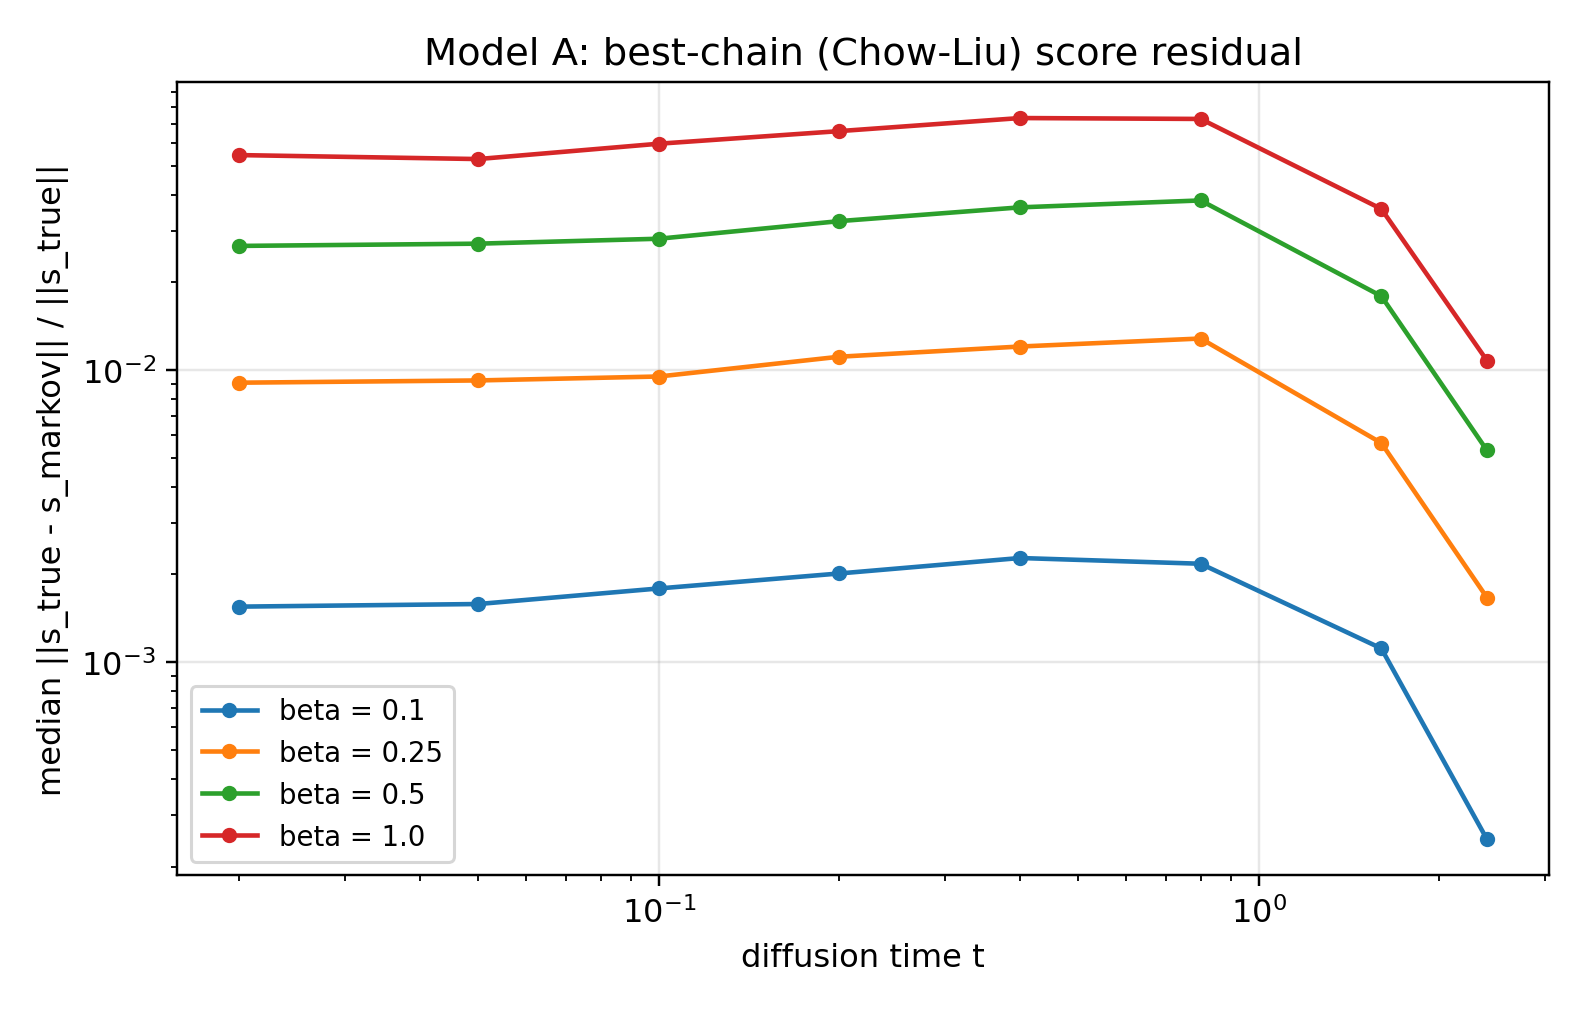

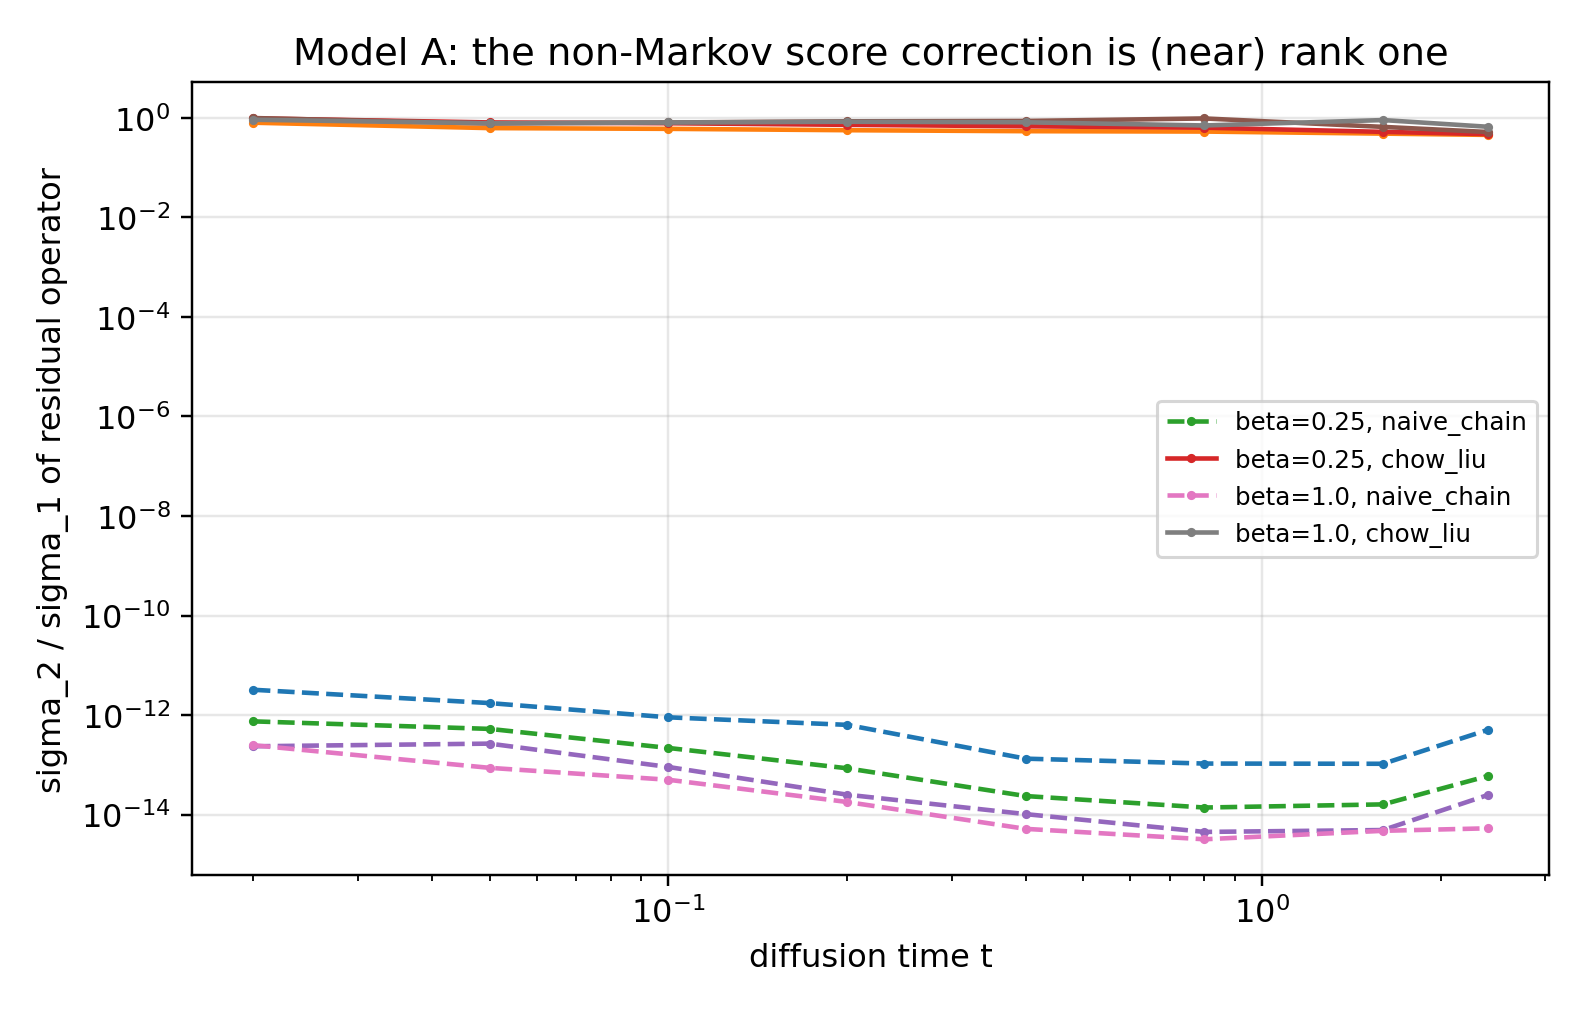

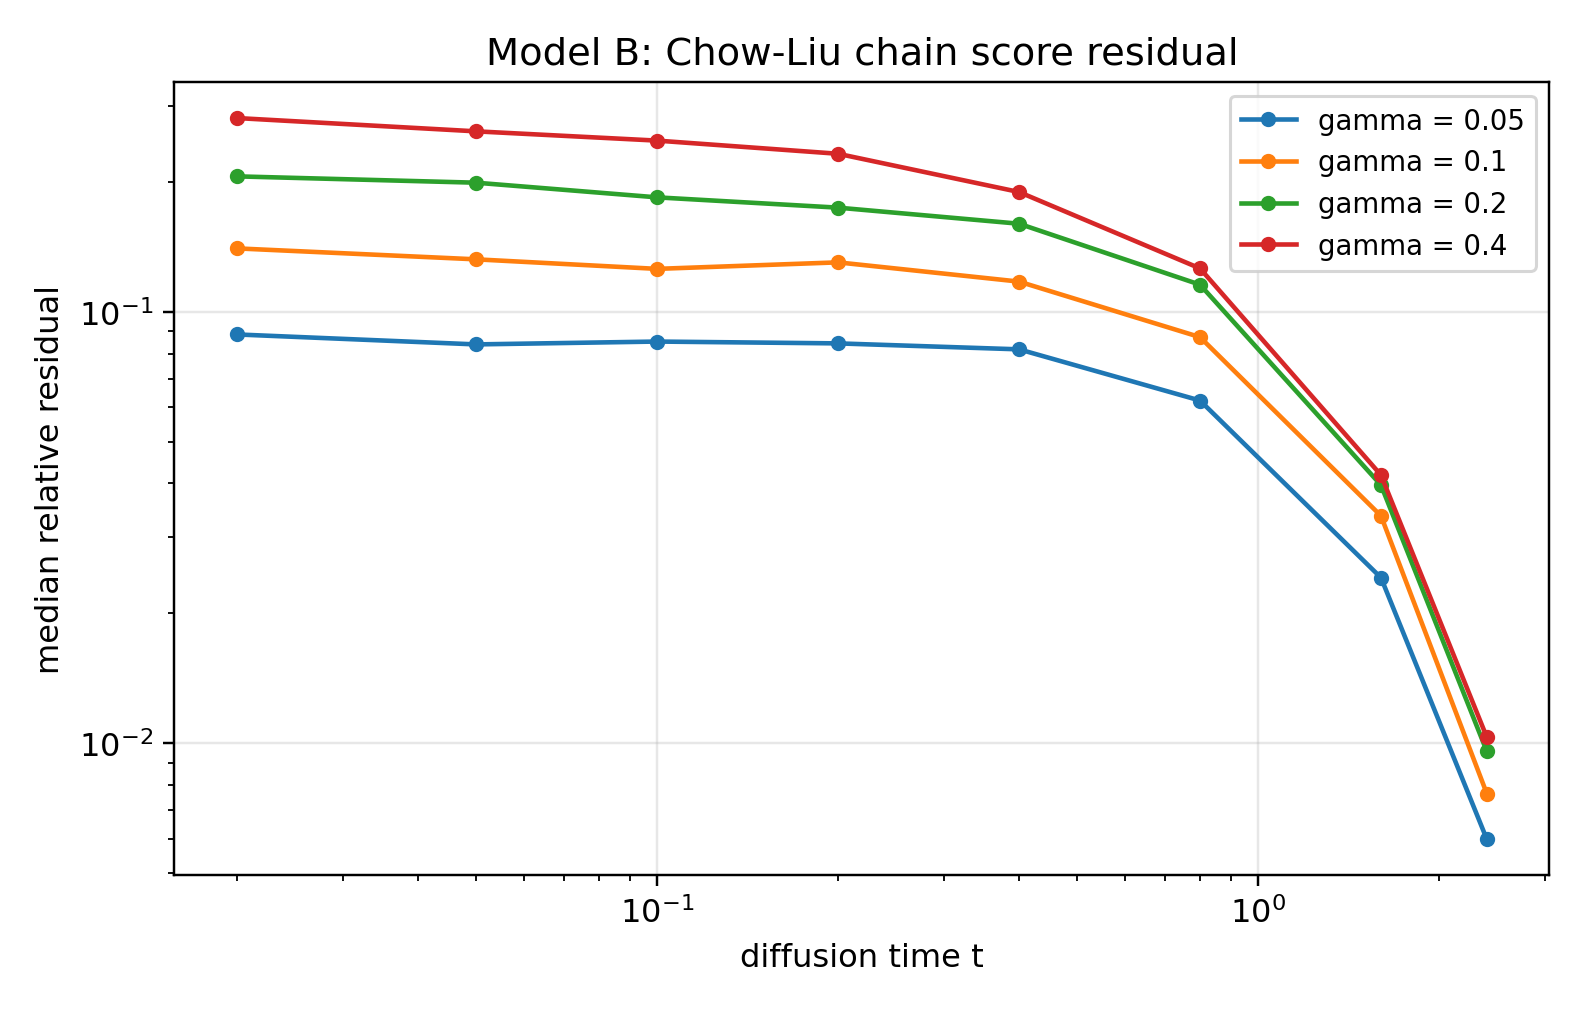

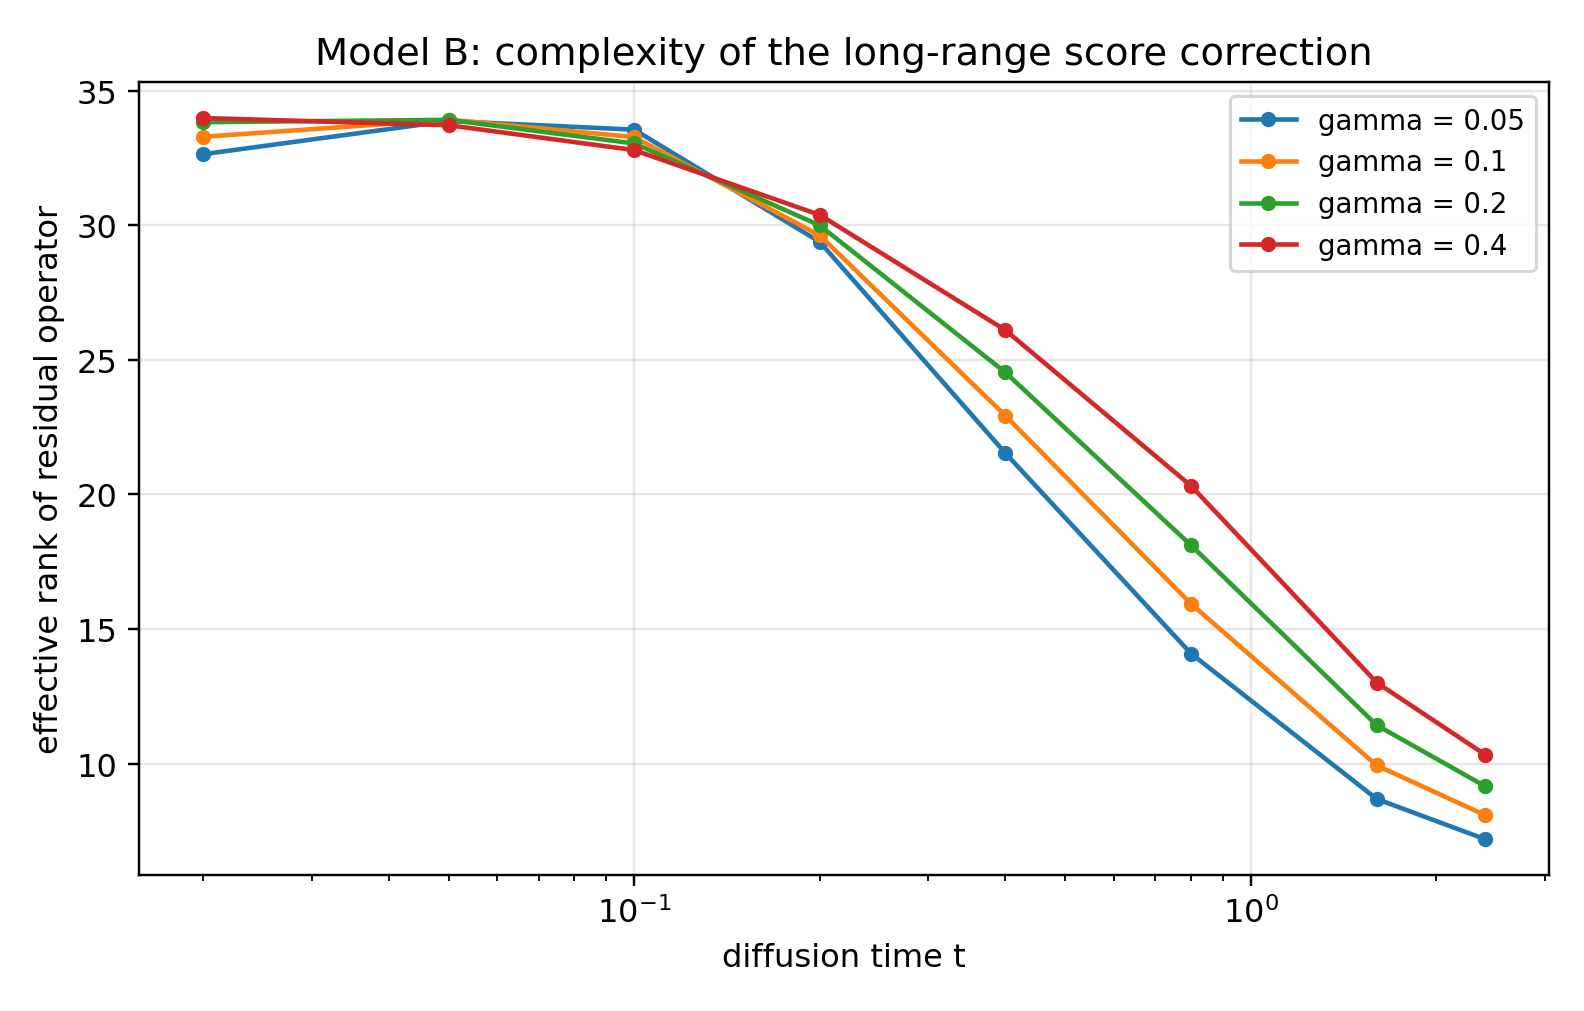

In [3]:
show("modelA_residual_norm.png", "modelA_rank_one_dominance.png",
     "modelB_residual_norm.png", "modelB_effective_rank.png", exp=exp)

## Hybrid learning: sample and parameter efficiency

In [4]:
hyb = pd.read_csv(OUT / exp / "hybrid_learning.csv")
hyb

,sweep,mode,n_train,width,n_params,test_rel_error,markov_baseline_rel_error
0,sample_efficiency,direct,64,64,9576,0.8829,0.03143
1,sample_efficiency,hybrid,64,64,9576,0.2287,0.03143
2,sample_efficiency,direct,256,64,9576,0.7524,0.03143
3,sample_efficiency,hybrid,256,64,9576,0.06039,0.03143
4,sample_efficiency,direct,1024,64,9576,0.2926,0.03143
5,sample_efficiency,hybrid,1024,64,9576,0.01491,0.03143
6,sample_efficiency,direct,4096,64,9576,0.2018,0.03143
7,sample_efficiency,hybrid,4096,64,9576,0.01352,0.03143
8,parameter_efficiency,direct,1024,16,1656,0.7751,0.03143
9,parameter_efficiency,hybrid,1024,16,1656,0.01726,0.03143


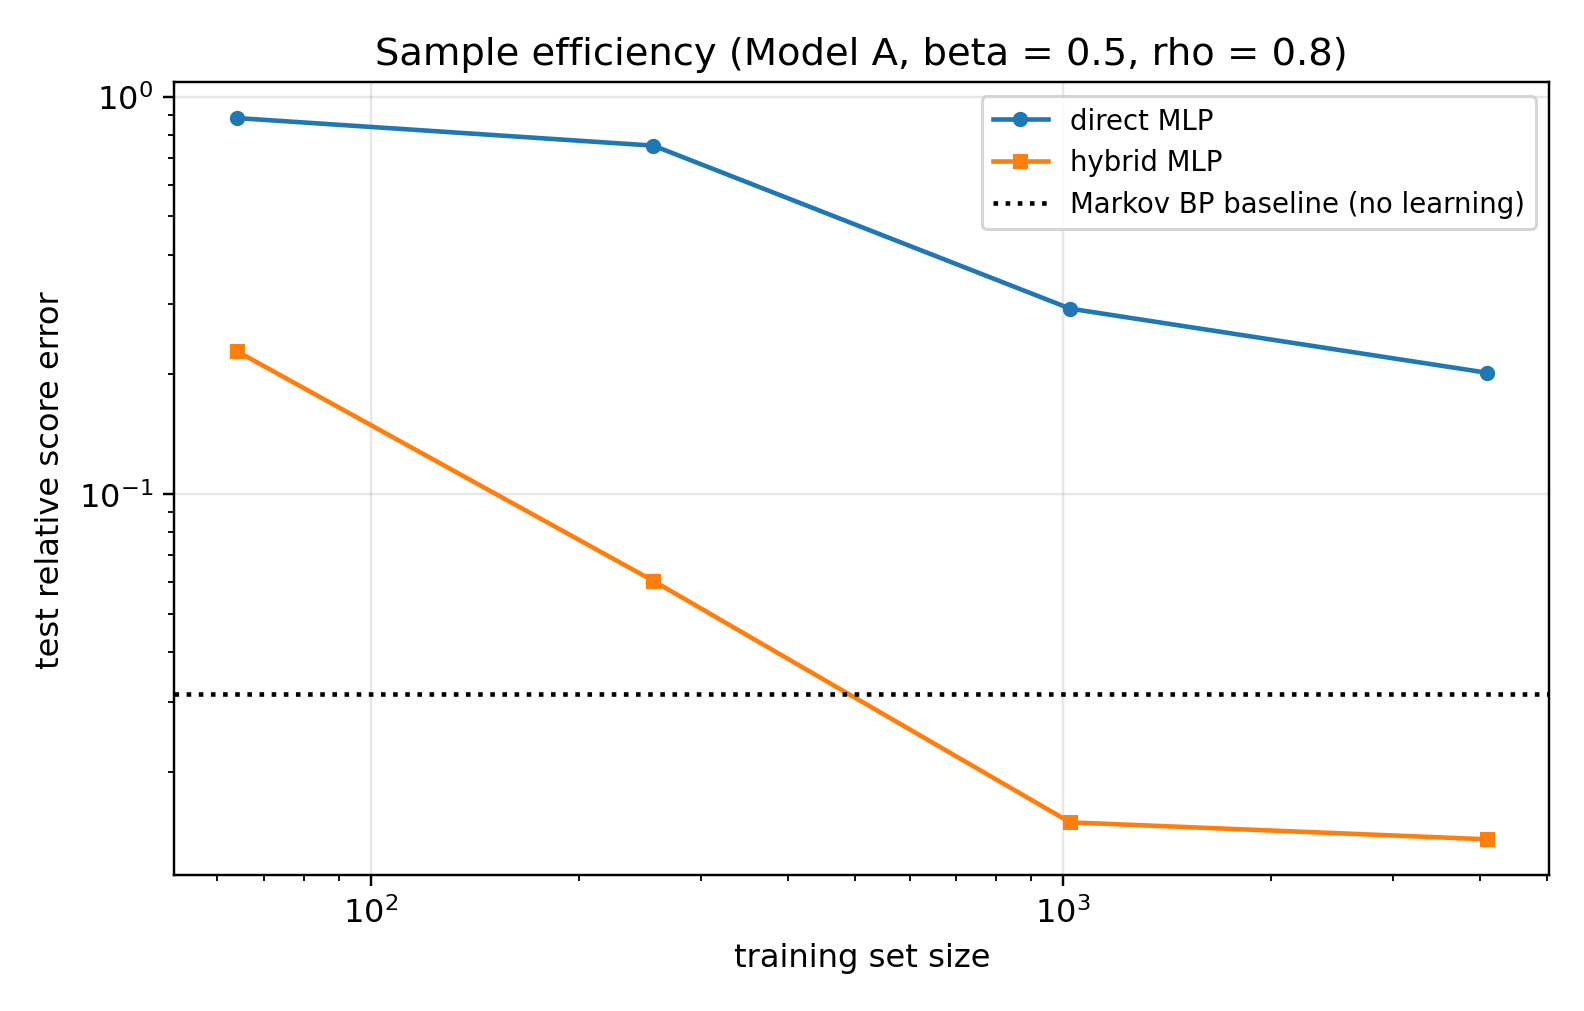

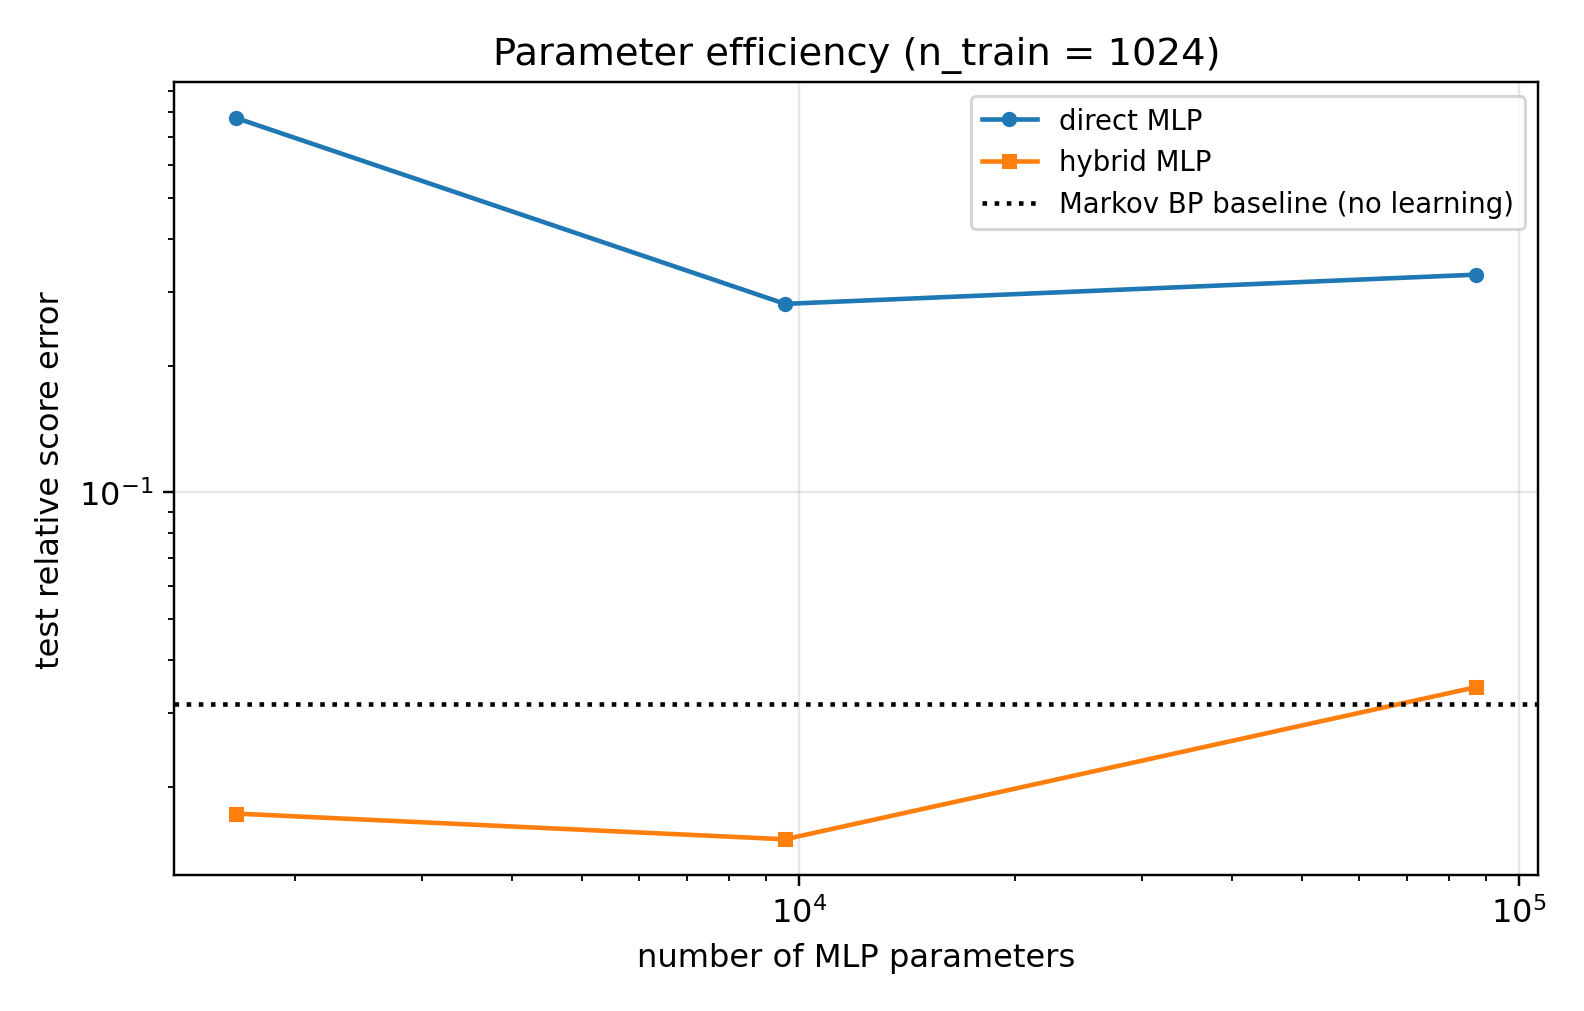

In [5]:
show("hybrid_sample_efficiency.png", "hybrid_parameter_efficiency.png", exp=exp)

The residual learner beats the direct score net by an order of magnitude at every
training-set size and parameter count, and beats the no-learning Markov baseline from
256 samples on. The direct net does not reach the *free* Markov baseline even with
4096 samples. Caveat: the Markov model is known here, not estimated; this isolates the
value of the structural prior, not of the estimation pipeline.